In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset/politifact_real.csv
/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset/politifact_fake.csv
/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset/gossipcop_real.csv
/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset/gossipcop_fake.csv


In [26]:
import os 
#List the files in kaggle input directory to verify that dataset has been uploaded 
print(os.listdir("/kaggle/input/"))

['datasets']


In [27]:
# Display all files inside the FakeNewsNet dataset folder 
# Confirms that the CSV files are present 
print (os.listdir("/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset"))

['politifact_real.csv', 'politifact_fake.csv', 'gossipcop_real.csv', 'gossipcop_fake.csv']


In [28]:
import pandas as pd
#define the file path to the dataset directory 
path = "/kaggle/input/datasets/nicoleudoh/fakenewsnetdataset/"
# Load each dataset into pandas Dataframe 
# Each file contains real or fake news articles 
politifact_fake = pd.read_csv(path + "politifact_fake.csv")
politifact_real = pd.read_csv(path + "politifact_real.csv")
gossipcop_fake = pd.read_csv(path + "gossipcop_fake.csv")
gossipcop_real = pd.read_csv(path + "gossipcop_real.csv")


In [29]:
# Assign labels to each dataset for supervised learning 
# Fake news =1 , Real news = 0
politifact_fake["label"]= 1
politifact_real["label"]= 0
gossipcop_fake["label"]= 1
gossipcop_real["label"]= 0 

In [30]:
# Combine all datasets into a single Dataframe 
# ignore_index= True resets the index after merging
df = pd.concat([
    politifact_fake,
    politifact_real,
    gossipcop_fake,
    gossipcop_real],
    ignore_index=True)
              

In [31]:
# Display the first few rows of the dataset to understand the structure and contents
print(df.head())

# Display the shape of the dataset 
print(df.shape)

# Display column names 
print(df.columns)

                id                                           news_url  \
0  politifact15014          speedtalk.com/forum/viewtopic.php?t=51650   
1  politifact15156  politics2020.info/index.php/2018/03/13/court-o...   
2  politifact14745  www.nscdscamps.org/blog/category/parenting/467...   
3  politifact14355  https://howafrica.com/oscar-pistorius-attempts...   
4  politifact15371  http://washingtonsources.org/trump-votes-for-d...   

                                               title  \
0  BREAKING: First NFL Team Declares Bankruptcy O...   
1  Court Orders Obama To Pay $400 Million In Rest...   
2  UPDATE: Second Roy Moore Accuser Works For Mic...   
3         Oscar Pistorius Attempts To Commit Suicide   
4        Trump Votes For Death Penalty For Being Gay   

                                           tweet_ids  label  
0  937349434668498944\t937379378006282240\t937380...      1  
1  972666281441878016\t972678396575559680\t972827...      1  
2  929405740732870656\t929439450400264

In [32]:
# Count the number of fake (1) and real (0) news occurrence 
# Helps identify class imbalnce in the dataset
print(df["label"].value_counts())

label
0    17441
1     5755
Name: count, dtype: int64


In [33]:
# Keep only the title and label columns
df = df[["title", "label"]].copy()

# Remove row with mising title values
df = df.dropna(subset=["title"])

# Rename the title column to text
df = df.rename(columns={'title':'text'})

# Check the cleaned result
print(df.head())
print(df.shape)
print(df["label"].value_counts())


                                                text  label
0  BREAKING: First NFL Team Declares Bankruptcy O...      1
1  Court Orders Obama To Pay $400 Million In Rest...      1
2  UPDATE: Second Roy Moore Accuser Works For Mic...      1
3         Oscar Pistorius Attempts To Commit Suicide      1
4        Trump Votes For Death Penalty For Being Gay      1
(23196, 2)
label
0    17441
1     5755
Name: count, dtype: int64


In [34]:
print(df.head())
print(df.columns)

                                                text  label
0  BREAKING: First NFL Team Declares Bankruptcy O...      1
1  Court Orders Obama To Pay $400 Million In Rest...      1
2  UPDATE: Second Roy Moore Accuser Works For Mic...      1
3         Oscar Pistorius Attempts To Commit Suicide      1
4        Trump Votes For Death Penalty For Being Gay      1
Index(['text', 'label'], dtype='object')


In [35]:
import re

# Function to clean text data
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

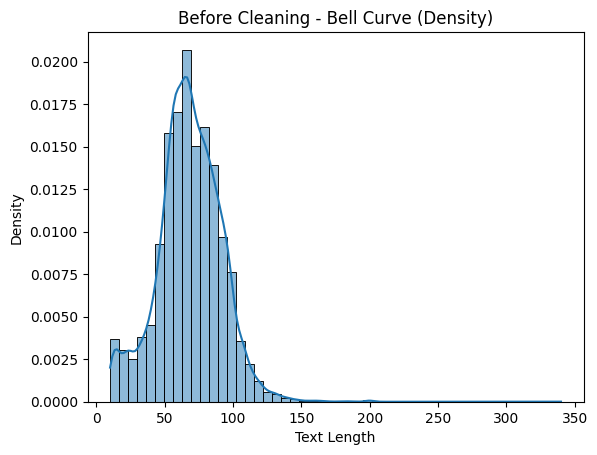

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# BEFORE CLEANING
df["text_length_before"] = df["text"].apply(lambda x: len(str(x)))

sns.histplot(df["text_length_before"], bins=50, kde=True, stat="density")
plt.title("Before Cleaning - Bell Curve (Density)")
plt.xlabel("Text Length")
plt.ylabel("Density")
plt.show()

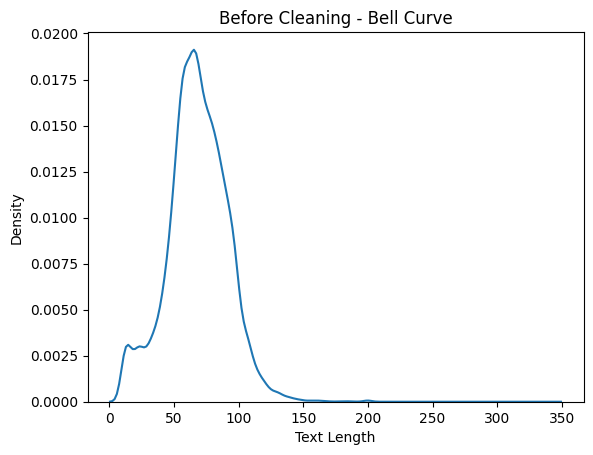

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(df["text_length_before"], fill=False)
plt.title("Before Cleaning - Bell Curve")
plt.xlabel("Text Length")
plt.ylabel("Density")
plt.show()

In [38]:
# Apply the cleaning function to the text column
df["clean_text"] = df["text"].apply(clean_text)

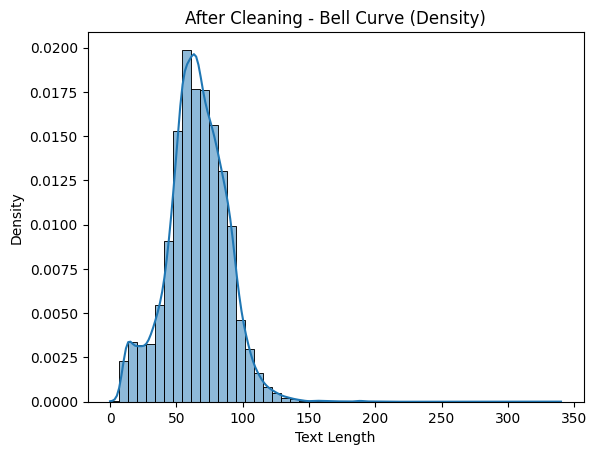

In [39]:
# AFTER CLEANING

# Create numerical column
df["text_length_after"] = df["clean_text"].apply(lambda x: len(str(x)))

sns.histplot(df["text_length_after"], bins=50, kde=True, stat="density")
plt.title("After Cleaning - Bell Curve (Density)")
plt.xlabel("Text Length")
plt.ylabel("Density")
plt.show()

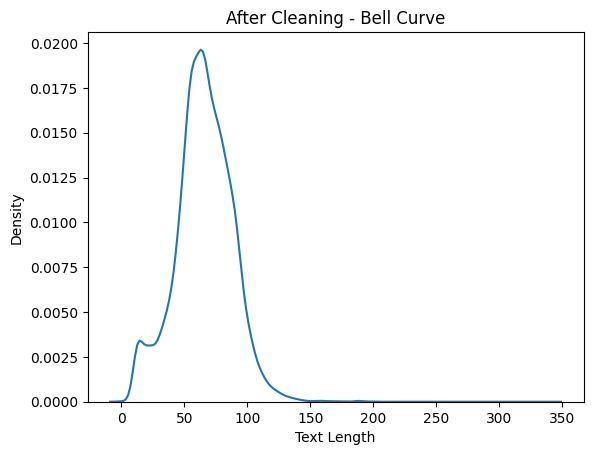

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df["text_length_after"], fill=False)
plt.title("After Cleaning - Bell Curve")
plt.xlabel("Text Length")
plt.ylabel("Density")
plt.show()

In [41]:
print(df[["text", "clean_text"]].head())

                                                text  \
0  BREAKING: First NFL Team Declares Bankruptcy O...   
1  Court Orders Obama To Pay $400 Million In Rest...   
2  UPDATE: Second Roy Moore Accuser Works For Mic...   
3         Oscar Pistorius Attempts To Commit Suicide   
4        Trump Votes For Death Penalty For Being Gay   

                                          clean_text  
0  breaking first nfl team declares bankruptcy ov...  
1   court orders obama to pay million in restitution  
2  update second roy moore accuser works for mich...  
3         oscar pistorius attempts to commit suicide  
4        trump votes for death penalty for being gay  


In [42]:
# ADVANCED PREPROCESSING 

# Import libraries needed for numerical processing and scaling 
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Make a copy of the cleaned dataframe to keep the original unchanged 
df_processed = df.copy()


In [43]:
# OUTLIER HANDLING USING IQR
# --------------------------------

# Calculate the first quartile (25%) and third quartile (75%)
Q1 = df_processed["text_length_after"].quantile(0.25)
Q3 = df_processed["text_length_after"].quantile(0.75)

# Calculate the interquartile range
IQR = Q3 - Q1

# Keep only rows within the acceptable range, removing extremely small or large text lengths
df_processed = df_processed[
    (df_processed["text_length_after"] >= Q1 - 1.5 * IQR) &
    (df_processed["text_length_after"] <= Q3 + 1.5 * IQR)
]

In [44]:
# LOG TRANSFORMATION 
# --------------------------------

# Apply log transformation to reduce skewness
# log1p means log(1 + x), which is safer when values include 0
df_processed["log_length"] = np.log1p(df_processed["text_length_after"])

In [45]:
# FEATURE SCALING
# --------------------------------

# Create the scaler
scaler = MinMaxScaler()

# Scale the log-transformed values into the range 0 to 1
df_processed["scaled_length"] = scaler.fit_transform(df_processed[["log_length"]])

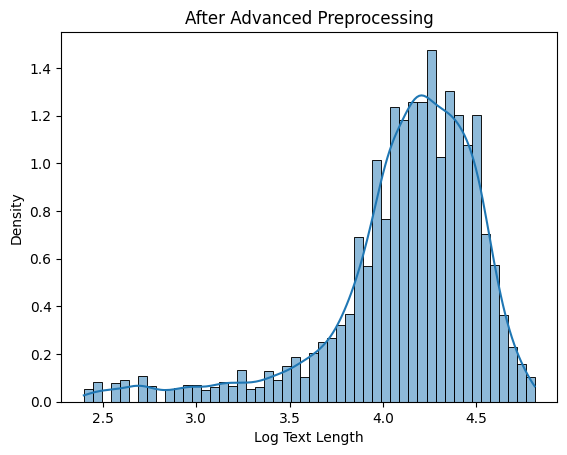

In [52]:
# VISUALISE THE IMPROVED DISTRIBUTION
# --------------------------------

# Plot the bell curve after advanced preprocessing
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_processed["log_length"], bins=50, kde=True, stat="density")
plt.title("After Advanced Preprocessing")
plt.xlabel("Log Text Length")
plt.ylabel("Density")
plt.show()

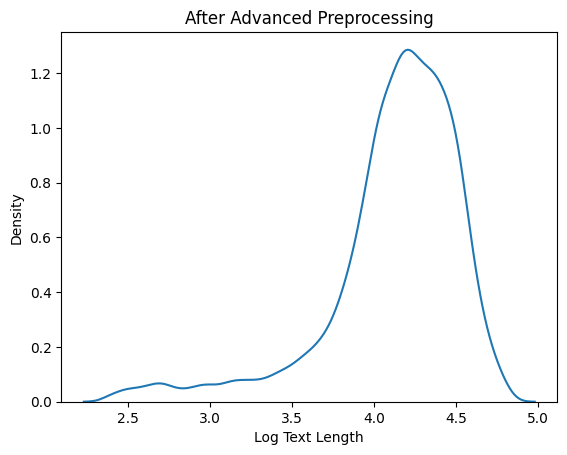

In [51]:
sns.kdeplot(df_processed["log_length"], fill=False)
plt.title("After Advanced Preprocessing")
plt.xlabel("Log Text Length")
plt.ylabel("Density")
plt.show()

In [46]:
X=df["clean_text"]
Y=df["label"]

In [47]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
vectorizer= TfidfVectorizer(stop_words= 'english')

# Fit on training data and transform it 
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data using the same TF-IDF vectorizer
X_test_tfidf = vectorizer.transform( X_test)

# Check shapes 
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(18556, 17073)
(4640, 17073)
